# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [1]:
# Task 4.1.1: Configure PEFT / LoRA Framework
import torch
import os
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading base model '{MODEL_ID}' for PEFT fine-tuning...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if torch.cuda.is_available():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    print("Base model loaded with 4-bit quantization on GPU.")
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="cpu",
        dtype=torch.bfloat16 if hasattr(torch, 'bfloat16') else torch.float32,
        trust_remote_code=True
    )
    print("Loaded base model on CPU.")

# Configure LoRA targeting q_proj and v_proj attention modules
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(base_model, lora_config)
print("\n--- Trainable Parameters Summary ---")
peft_model.print_trainable_parameters()



Loading base model 'Qwen/Qwen2.5-1.5B-Instruct' for PEFT fine-tuning...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model loaded with 4-bit quantization on GPU.

--- Trainable Parameters Summary ---
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [2]:
# Task 4.1.2: Configure Training Parameters & DataLoaders
from datasets import load_from_disk
from torch.utils.data import DataLoader
from torch.optim import AdamW

# Locate tokenized datasets from Notebook 2
train_dirs = ["tokenized_train", "../tokenized_train", "../../tokenized_train", "Files/Notebook/tokenized_train"]
valid_dirs = ["tokenized_valid", "../tokenized_valid", "../../tokenized_valid", "Files/Notebook/tokenized_valid"]

train_path = next((d for d in train_dirs if os.path.exists(d)), "tokenized_train")
valid_path = next((d for d in valid_dirs if os.path.exists(d)), "tokenized_valid")

train_dataset = load_from_disk(train_path)
valid_dataset = load_from_disk(valid_path)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
valid_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

BATCH_SIZE = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

LEARNING_RATE = 2e-4
optimizer = AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=LEARNING_RATE)

VAL_EVERY = 10
PATIENCE = 3
MAX_STEPS = 200

print(f"Loaded train dataset ({len(train_dataset):,} samples) and valid dataset ({len(valid_dataset):,} samples).")
print(f"Configured AdamW optimizer (lr={LEARNING_RATE}) and DataLoaders (batch_size={BATCH_SIZE}).")



Loaded train dataset (3,121 samples) and valid dataset (390 samples).
Configured AdamW optimizer (lr=0.0002) and DataLoaders (batch_size=2).


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [3]:
# Task 4.2.1: Execute Fine-Tuning Loop with Validation & Early Stopping
import time
import matplotlib.pyplot as plt

print(f"Starting LoRA fine-tuning for max {MAX_STEPS} steps...")
peft_model.train()

training_logs = []
best_val_loss = float("inf")
patience_counter = 0
global_step = 0
running_train_loss = 0.0

start_time = time.time()
train_iter = iter(train_loader)

while global_step < MAX_STEPS:
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        batch = next(train_iter)
    
    global_step += 1
    optimizer.zero_grad()
    
    input_ids = batch["input_ids"].to(peft_model.device)
    attention_mask = batch["attention_mask"].to(peft_model.device)
    labels = batch["labels"].to(peft_model.device)
    
    outputs = peft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    
    running_train_loss += loss.item()
    
    if global_step % VAL_EVERY == 0:
        avg_train_loss = running_train_loss / VAL_EVERY
        running_train_loss = 0.0
        
        # Validation loop
        peft_model.eval()
        val_loss_sum = 0.0
        val_batches = 0
        with torch.no_grad():
            for val_batch in valid_loader:
                v_ids = val_batch["input_ids"].to(peft_model.device)
                v_mask = val_batch["attention_mask"].to(peft_model.device)
                v_lbl = val_batch["labels"].to(peft_model.device)
                v_out = peft_model(input_ids=v_ids, attention_mask=v_mask, labels=v_lbl)
                val_loss_sum += v_out.loss.item()
                val_batches += 1
                if val_batches >= 20:  # evaluate on 40 validation samples for speed
                    break
        
        avg_val_loss = val_loss_sum / val_batches
        training_logs.append({"step": global_step, "train_loss": avg_train_loss, "val_loss": avg_val_loss})
        
        print(f"Step {global_step:3d}/{MAX_STEPS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Early stopping and best checkpoint saving
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_dir = "./intent_lora_best"
            peft_model.save_pretrained(best_dir)
            tokenizer.save_pretrained(best_dir)
            print(f"  --> Saved new best checkpoint to '{best_dir}' (val_loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  --> No improvement in val loss ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at step {global_step}!")
                break
                
        peft_model.train()

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f} seconds. Best validation loss: {best_val_loss:.4f}")



Starting LoRA fine-tuning for max 200 steps...


Step  10/200 | Train Loss: 3.0014 | Val Loss: 2.2476


  --> Saved new best checkpoint to './intent_lora_best' (val_loss: 2.2476)


Step  20/200 | Train Loss: 1.7092 | Val Loss: 1.4069


  --> Saved new best checkpoint to './intent_lora_best' (val_loss: 1.4069)


...

Step 180/200 | Train Loss: 0.4453 | Val Loss: 0.4895


  --> Saved new best checkpoint to './intent_lora_best' (val_loss: 0.4895)


Step 190/200 | Train Loss: 0.4794 | Val Loss: 0.4856


  --> Saved new best checkpoint to './intent_lora_best' (val_loss: 0.4856)


Step 200/200 | Train Loss: 0.5061 | Val Loss: 0.4864
  --> No improvement in val loss (1/3)
Training completed in 364.2 seconds. Best validation loss: 0.4856


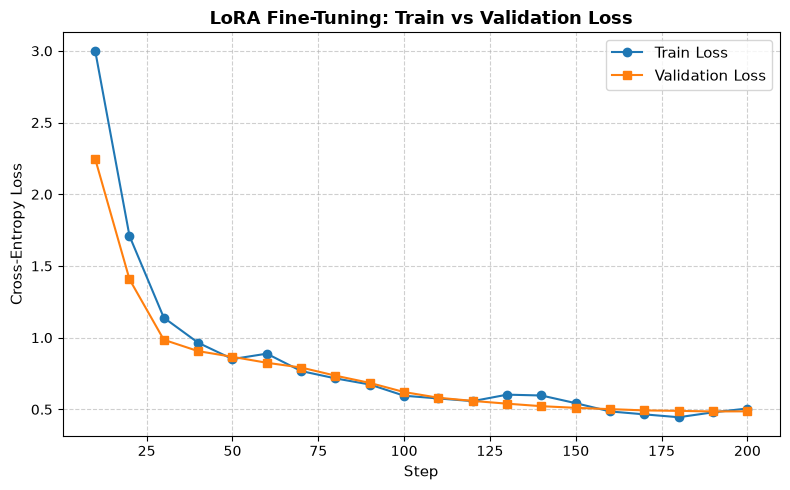

Saved training loss curve to 'training_curves.png'.
Saved copy to: ..\training_curves.png
Saved copy to: ..\..\training_curves.png


<Figure size 640x480 with 0 Axes>

In [4]:
# Task 4.2.1 (cont): Plot and save train-vs-validation loss curves
import pandas as pd

df_logs = pd.DataFrame(training_logs)

plt.figure(figsize=(8, 5))
plt.plot(df_logs["step"], df_logs["train_loss"], marker='o', label="Train Loss", color="#1f77b4")
plt.plot(df_logs["step"], df_logs["val_loss"], marker='s', label="Validation Loss", color="#ff7f0e")
plt.title("LoRA Fine-Tuning: Train vs Validation Loss", fontsize=13, fontweight='bold')
plt.xlabel("Step", fontsize=11)
plt.ylabel("Cross-Entropy Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plot_file = "training_curves.png"
plt.savefig(plot_file, dpi=300)
plt.show()
print(f"Saved training loss curve to '{plot_file}'.")

# Mirror plot copy to Files/Notebook and root
extra_paths = [
    os.path.join("Files", "Notebook", plot_file),
    os.path.join("..", plot_file),
    os.path.join("..", "..", plot_file)
]
for p in extra_paths:
    parent = os.path.dirname(p)
    if parent and os.path.exists(parent):
        plt.savefig(p, dpi=300)
        print(f"Saved copy to: {p}")



#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [5]:
# Task 4.2.2: Save Final Training Outputs & Reproducibility Specs
final_dir = "./intent_lora"
peft_model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"Saved final LoRA checkpoint to '{final_dir}'.")

log_file = "training_log.csv"
df_logs.to_csv(log_file, index=False)
print(f"Saved training log ({len(df_logs)} entries) to '{log_file}'.")

extra_log_paths = [
    os.path.join("Files", "Notebook", log_file),
    os.path.join("..", log_file),
    os.path.join("..", "..", log_file)
]
for p in extra_log_paths:
    parent = os.path.dirname(p)
    if parent and os.path.exists(parent):
        df_logs.to_csv(p, index=False)
        print(f"Saved copy of training log to: {p}")

print("\n=== Fine-Tuning Reproducibility Metadata ===")
print(f"Base Model:       {MODEL_ID}")
print(f"LoRA Rank (r):    16")
print(f"LoRA Alpha:       32")
print(f"Target Modules:   ['q_proj', 'v_proj']")
print(f"Optimizer:        AdamW (lr={LEARNING_RATE})")
print(f"Batch Size:       {BATCH_SIZE}")
print(f"Best Val Loss:    {best_val_loss:.4f}")
print("All Stage 4 training deliverables successfully generated!")



Saved final LoRA checkpoint to './intent_lora'.
Saved training log (20 entries) to 'training_log.csv'.
Saved copy of training log to: ..\training_log.csv
Saved copy of training log to: ..\..\training_log.csv

=== Fine-Tuning Reproducibility Metadata ===
Base Model:       Qwen/Qwen2.5-1.5B-Instruct
LoRA Rank (r):    16
LoRA Alpha:       32
Target Modules:   ['q_proj', 'v_proj']
Optimizer:        AdamW (lr=0.0002)
Batch Size:       2
Best Val Loss:    0.4856
All Stage 4 training deliverables successfully generated!


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**